In [1]:
from my_functions import * 

In [2]:
added_tracks = pd.read_csv("all_tracks_please_please_please.csv",dtype={'topic': 'int'})
added_tracks['Writers'] = added_tracks['Writers'].apply(ast.literal_eval)
added_tracks['Producers'] = added_tracks['Producers'].apply(ast.literal_eval)
features = ["danceability","energy","loudness","speechiness","acousticness","instrumentalness","liveness","valence","tempo"]

In [3]:
grouped_by_artist = added_tracks.groupby("Artist Name", as_index=False).agg({
    "danceability":"mean",
    "energy":"mean",
    "loudness":"mean",
    "speechiness":"mean",
    "acousticness":"mean",
    "instrumentalness":"mean",
    "liveness":"mean",
    "valence":"mean",
    "tempo":"mean",
})

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(grouped_by_artist.iloc[:, 1:])
X_scaled_df = pd.DataFrame(X_scaled, columns=[features], index=grouped_by_artist.index)

In [5]:
X_scaled_df

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.935073,-0.069673,0.961163,0.972542,-1.087314,2.576552,-0.065063,-0.528127,0.875396
1,-0.005924,0.708706,1.472070,-0.787651,-0.224093,-0.179291,1.752226,1.125861,-1.275038
2,-1.058564,-0.765889,0.317013,-0.777041,0.607921,-0.179291,-1.075568,-0.919449,-0.281243
3,0.879251,0.881679,0.481941,-0.286861,-0.338139,-0.109985,-0.940140,-0.627262,-1.234265
4,0.089771,0.596273,0.285046,0.887662,0.418709,-0.179291,1.717501,0.311911,0.050422
...,...,...,...,...,...,...,...,...,...
121,-2.486008,1.694652,0.606414,-0.573330,-1.115204,-0.179291,-0.192389,-1.696876,-1.315811
122,0.647989,0.821138,1.541096,-0.437522,-0.871042,-0.171869,-0.840594,0.332781,1.907463
123,0.879251,-1.341025,0.336533,2.362447,-0.021921,-0.179258,-1.123026,0.223211,1.988265
124,0.640015,-0.649133,-0.471413,-0.356887,-0.478104,-0.179291,2.458306,0.880632,0.337075


In [6]:
result = pd.concat([grouped_by_artist.iloc[:, [0]], X_scaled_df], axis=1)
result

,Artist Name,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,21 Savage,0.935073,-0.069673,0.961163,0.972542,-1.087314,2.576552,-0.065063,-0.528127,0.875396
1,24kGoldn,-0.005924,0.708706,1.472070,-0.787651,-0.224093,-0.179291,1.752226,1.125861,-1.275038
2,Adele,-1.058564,-0.765889,0.317013,-0.777041,0.607921,-0.179291,-1.075568,-0.919449,-0.281243
3,Anitta,0.879251,0.881679,0.481941,-0.286861,-0.338139,-0.109985,-0.940140,-0.627262,-1.234265
4,Arcángel,0.089771,0.596273,0.285046,0.887662,0.418709,-0.179291,1.717501,0.311911,0.050422
...,...,...,...,...,...,...,...,...,...,...
121,WILLOW,-2.486008,1.694652,0.606414,-0.573330,-1.115204,-0.179291,-0.192389,-1.696876,-1.315811
122,Yandel,0.647989,0.821138,1.541096,-0.437522,-0.871042,-0.171869,-0.840594,0.332781,1.907463
123,Yng Lvcas,0.879251,-1.341025,0.336533,2.362447,-0.021921,-0.179258,-1.123026,0.223211,1.988265
124,blackbear,0.640015,-0.649133,-0.471413,-0.356887,-0.478104,-0.179291,2.458306,0.880632,0.337075


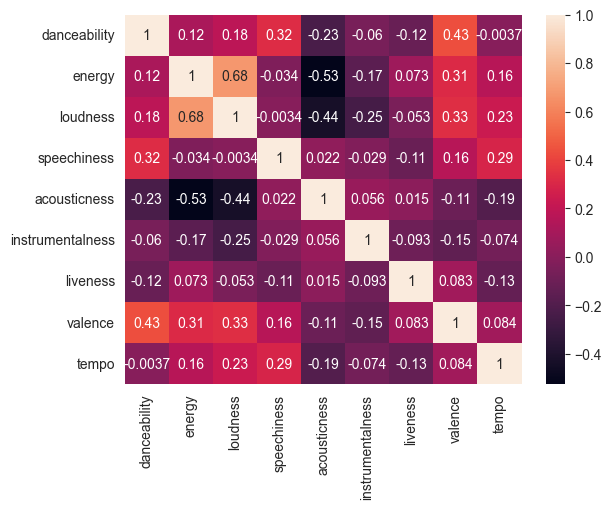

In [7]:
sn.heatmap(X_scaled_df.corr(), annot=True)
plt.show()

In [8]:
eval_metrics= pd.DataFrame(columns=["k", "tot.within.ss"])
silhouette=dict()
for k in range(2,10):
    seed(10)

    kmeans= KMeans(n_clusters=k,n_init=1000,max_iter=20)
    kmeans.fit(X_scaled_df)
    labels=kmeans.labels_

    eval_metrics.loc[len(eval_metrics.index)]=[k,kmeans.inertia_]
    sil=silhouette_score(X_scaled_df,labels,metric="euclidean",sample_size=1000)
    silhouette.update({k:sil})
    print ("Silhouette score for k(clusters) = "+str(k)+" is "
           +str(round(sil,3)))
print(eval_metrics)
print(max(silhouette,key=silhouette.get))

Silhouette score for k(clusters) = 2 is 0.187
Silhouette score for k(clusters) = 3 is 0.168
Silhouette score for k(clusters) = 4 is 0.172
Silhouette score for k(clusters) = 5 is 0.165
Silhouette score for k(clusters) = 6 is 0.161
Silhouette score for k(clusters) = 7 is 0.151
Silhouette score for k(clusters) = 8 is 0.149
Silhouette score for k(clusters) = 9 is 0.174
     k  tot.within.ss
0  2.0     935.356830
1  3.0     825.952947
2  4.0     720.716560
3  5.0     655.523278
4  6.0     597.403783
5  7.0     546.529572
6  8.0     515.037026
7  9.0     485.709523
2


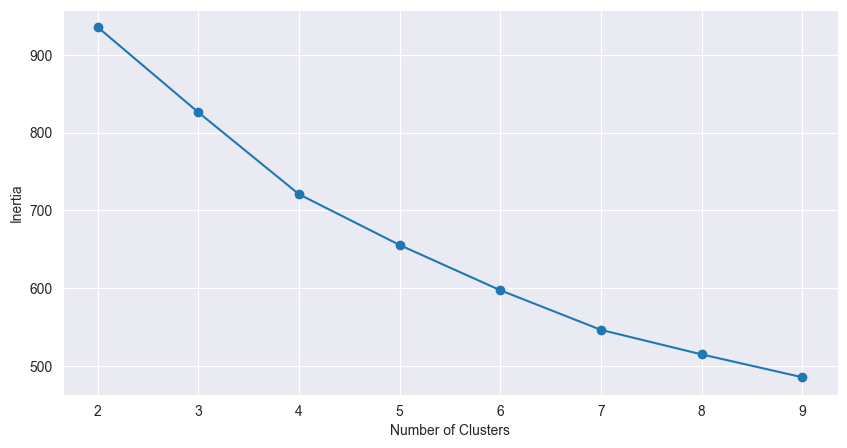

In [9]:
fig = plt.subplots(figsize=(10, 5))
plt.plot(eval_metrics.k, eval_metrics['tot.within.ss'], 'o-')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

In [10]:
kmeans = KMeans(n_clusters=4, n_init=1000, max_iter=20)
kmeans.fit(X_scaled_df)
kmeans.labels_
result["cluster"] = kmeans.labels_
result

,Artist Name,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster
0,21 Savage,0.935073,-0.069673,0.961163,0.972542,-1.087314,2.576552,-0.065063,-0.528127,0.875396,0
1,24kGoldn,-0.005924,0.708706,1.472070,-0.787651,-0.224093,-0.179291,1.752226,1.125861,-1.275038,3
2,Adele,-1.058564,-0.765889,0.317013,-0.777041,0.607921,-0.179291,-1.075568,-0.919449,-0.281243,1
3,Anitta,0.879251,0.881679,0.481941,-0.286861,-0.338139,-0.109985,-0.940140,-0.627262,-1.234265,3
4,Arcángel,0.089771,0.596273,0.285046,0.887662,0.418709,-0.179291,1.717501,0.311911,0.050422,3
...,...,...,...,...,...,...,...,...,...,...,...
121,WILLOW,-2.486008,1.694652,0.606414,-0.573330,-1.115204,-0.179291,-0.192389,-1.696876,-1.315811,3
122,Yandel,0.647989,0.821138,1.541096,-0.437522,-0.871042,-0.171869,-0.840594,0.332781,1.907463,3
123,Yng Lvcas,0.879251,-1.341025,0.336533,2.362447,-0.021921,-0.179258,-1.123026,0.223211,1.988265,0
124,blackbear,0.640015,-0.649133,-0.471413,-0.356887,-0.478104,-0.179291,2.458306,0.880632,0.337075,3


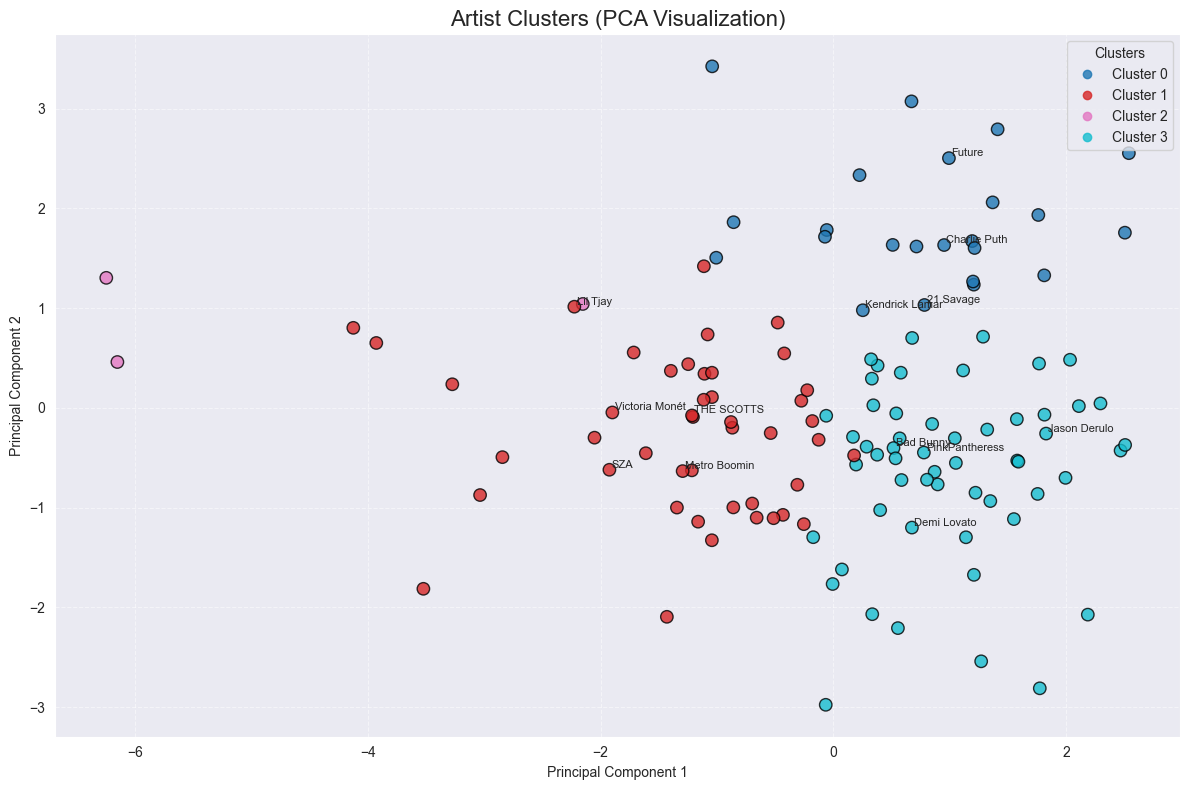

In [11]:
# Step 1: Reduce to 2D with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 2: Add PCA components to your dataframe for plotting
result["pca1"] = X_pca[:, 0]
result["pca2"] = X_pca[:, 1]

# Step 3: Plot
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    result["pca1"],
    result["pca2"],
    c=result["cluster"],
    cmap="tab10",
    s=80,
    alpha=0.8,
    edgecolors="k"
)

# Step 4: Add labels for a few points (optional)
# To avoid overcrowding, only label some artists (e.g., every 10th)
for i, row in result.iloc[::10].iterrows():  # show every 10th artist
    plt.text(row["pca1"] + 0.02, row["pca2"] + 0.02, row["Artist Name"], fontsize=8)

# Step 5: Add titles, labels, legend
plt.title("Artist Clusters (PCA Visualization)", fontsize=16)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

# Custom legend with cluster numbers
legend_labels = [f"Cluster {i}" for i in sorted(result['cluster'].unique())]
plt.legend(handles=scatter.legend_elements()[0], labels=legend_labels, title="Clusters")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

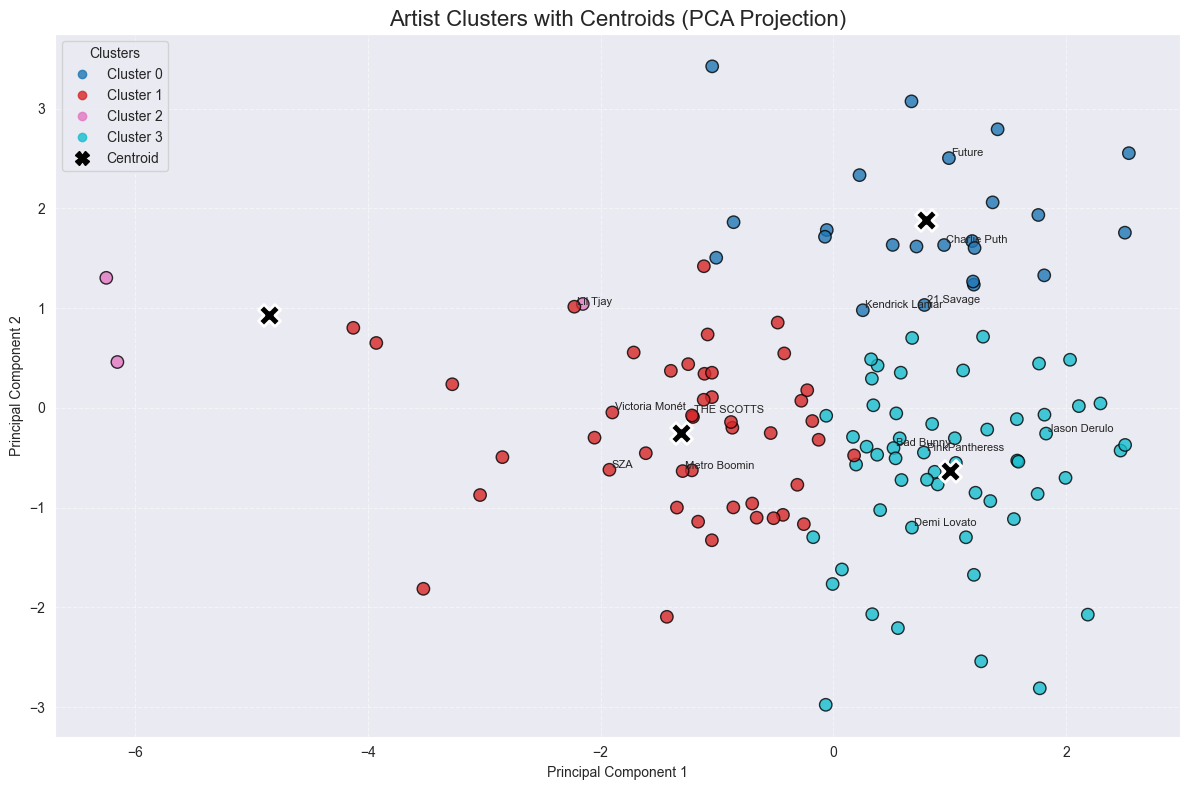

In [12]:
# Get centroids from the fitted KMeans model
centroids = kmeans.cluster_centers_
# Project centroids into PCA space
centroids_pca = pca.transform(centroids)

# Plot clusters as before
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    result["pca1"], result["pca2"],
    c=result["cluster"], cmap="tab10",
    s=80, alpha=0.8, edgecolors="k"
)

# Plot centroids
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c='black', s=250, marker='X', edgecolors='white', linewidths=2, label='Centroids'
)

# Add text labels for a few points
for i, row in result.iloc[::10].iterrows():
    plt.text(row["pca1"] + 0.02, row["pca2"] + 0.02, row["Artist Name"], fontsize=8)

# Legend, title, etc.
legend_labels = [f"Cluster {i}" for i in sorted(result['cluster'].unique())]
plt.legend(handles=scatter.legend_elements()[0] + [plt.Line2D([], [], color='black', marker='X', linestyle='', markersize=10)],
           labels=legend_labels + ["Centroid"],
           title="Clusters")

plt.title("Artist Clusters with Centroids (PCA Projection)", fontsize=16)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [13]:
cluster_means = result.groupby("cluster").mean(features)
print(cluster_means[features])

         danceability    energy  loudness  speechiness  acousticness  \
cluster                                                                
0            0.791774 -0.118243  0.177608     1.713418      0.093979   
1           -0.519908 -0.715572 -0.611716    -0.365566      0.524368   
2           -0.961097 -1.894218 -2.455444    -0.446443      1.429645   
3            0.146697  0.738236  0.560155    -0.393070     -0.546310   

         instrumentalness  liveness   valence     tempo  
cluster                                                  
0               -0.044702 -0.471612  0.464795  0.721096  
1               -0.147677  0.103694 -0.575228 -0.212657  
2                5.498725 -0.619681 -1.217299 -0.760884  
3               -0.160410  0.146180  0.342671 -0.086055  


In [14]:
sabrina_cluster = result.loc[result["Artist Name"] == "Sabrina Carpenter", "cluster"].values[0]
print(f"Sabrina Carpenter belongs to cluster {sabrina_cluster}")
similar_artists = result.loc[result["cluster"] == sabrina_cluster, "Artist Name"].tolist()
print(f"Artists in the same cluster as Sabrina Carpenter:\n{similar_artists}")


Sabrina Carpenter belongs to cluster 3
Artists in the same cluster as Sabrina Carpenter:
['24kGoldn', 'Anitta', 'Arcángel', 'Ariana Grande', 'BENEE', 'BLACKPINK', 'BTS', 'Bad Bunny', 'Becky G', 'Beyoncé', 'Bizarrap', 'Black Eyed Peas', 'Camila Cabello', 'Coldplay', 'David Guetta', 'Demi Lovato', 'Doechii', 'Doja Cat', 'Dua Lipa', 'Ed Sheeran', 'Elton John', 'Grupo Frontera', 'Harry Styles', 'Internet Money', 'Jack Harlow', 'Jason Derulo', 'Jimin', 'Jonas Brothers', 'Juice WRLD', 'Jung Kook', 'Lady Gaga', 'Latto', 'Lil Nas X', 'Lizzo', 'Manuel Turizo', 'Marshmello', 'Miley Cyrus', 'Myke Towers', 'Måneskin', 'Niall Horan', 'OneRepublic', 'PinkPantheress', 'Post Malone', 'RAYE', 'Rauw Alejandro', 'Sabrina Carpenter', 'Saweetie', 'Selena Gomez', 'Surf Mesa', 'The Weeknd', 'Troye Sivan', 'Tyla', 'WILLOW', 'Yandel', 'blackbear']


In [15]:
# Get Sabrina’s feature vector
sabrina_vector = X_scaled[result.index[result["Artist Name"] == "Sabrina Carpenter"][0]]

# Compute distance from Sabrina to every other artist
result["distance_to_sabrina"] = [
    euclidean(sabrina_vector, X_scaled[i]) for i in range(len(X_scaled))
]

# Sort by smallest distance (most similar)
most_similar = result.sort_values("distance_to_sabrina").head(10)
print("Artists most similar to Sabrina Carpenter (based on audio features):")
print(most_similar[["Artist Name", "distance_to_sabrina", "cluster"]])


Artists most similar to Sabrina Carpenter (based on audio features):
           Artist Name  distance_to_sabrina  cluster
101  Sabrina Carpenter             0.000000        3
83         Myke Towers             0.905260        3
38          Elton John             1.105288        3
14            Bizarrap             1.180415        3
50        Jason Derulo             1.212147        3
35            Dua Lipa             1.277628        3
104       Selena Gomez             1.362139        3
9                  BTS             1.397219        3
81         Miley Cyrus             1.410032        3
5        Ariana Grande             1.477961        3


In [27]:
# Compute all pairwise similarities
similarities = cosine_similarity(X_scaled)

# Find Sabrina’s index
sabrina_index = result.index[result["Artist Name"] == "Sabrina Carpenter"][0]

# Sort by similarity (descending)
result["similarity_to_sabrina"] = similarities[sabrina_index]
most_similar = result.sort_values("similarity_to_sabrina", ascending=False).head(20)

print("Artists most similar to Sabrina Carpenter (cosine similarity):")
print(most_similar[["Artist Name", "similarity_to_sabrina", "cluster"]])


Artists most similar to Sabrina Carpenter (cosine similarity):
           Artist Name  similarity_to_sabrina  cluster
101  Sabrina Carpenter               1.000000        3
50        Jason Derulo               0.924038        3
83         Myke Towers               0.867704        3
35            Dua Lipa               0.865178        3
38          Elton John               0.829592        3
11             Becky G               0.818130        3
55           Jung Kook               0.799798        3
7                BENEE               0.793276        3
89         OneRepublic               0.772070        3
84            Måneskin               0.724635        3
14            Bizarrap               0.714174        3
9                  BTS               0.678431        3
8            BLACKPINK               0.671629        3
78      Meghan Trainor               0.659692        0
104       Selena Gomez               0.644985        3
81         Miley Cyrus               0.613310        3
11

In [17]:
# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(result[features])

# PCA for visualization
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

result['PC1'] = pca_result[:, 0]
result['PC2'] = pca_result[:, 1]

# Compute distances from Sabrina Carpenter
sabrina_vector = X_scaled[result['Artist Name'] == 'Sabrina Carpenter']

cosine_dist = cosine_distances(sabrina_vector, X_scaled).flatten()
euclidean_dist = euclidean_distances(sabrina_vector, X_scaled).flatten()

result['cosine_dist'] = cosine_dist
result['euclidean_dist'] = euclidean_dist


In [18]:
# Exclude Sabrina herself
df_sim = result[result['Artist Name'] != 'Sabrina Carpenter']

# Top 10 most similar based on each metric
top_cosine = df_sim.nsmallest(10, 'cosine_dist')
top_euclidean = df_sim.nsmallest(10, 'euclidean_dist')

In [19]:
# Get sets of artist names
cosine_set = set(top_cosine['Artist Name'])
euclidean_set = set(top_euclidean['Artist Name'])

# Intersection (both)
both_set = cosine_set & euclidean_set

# Only cosine or only Euclidean
only_cosine = cosine_set - both_set
only_euclidean = euclidean_set - both_set

# Add a column to mark similarity group
def label_similarity(row):
    if row['Artist Name'] in both_set:
        return 'Both'
    elif row['Artist Name'] in only_cosine:
        return 'Cosine Only'
    elif row['Artist Name'] in only_euclidean:
        return 'Euclidean Only'
    else:
        return 'Other'

result['similarity_group'] = result.apply(label_similarity, axis=1)


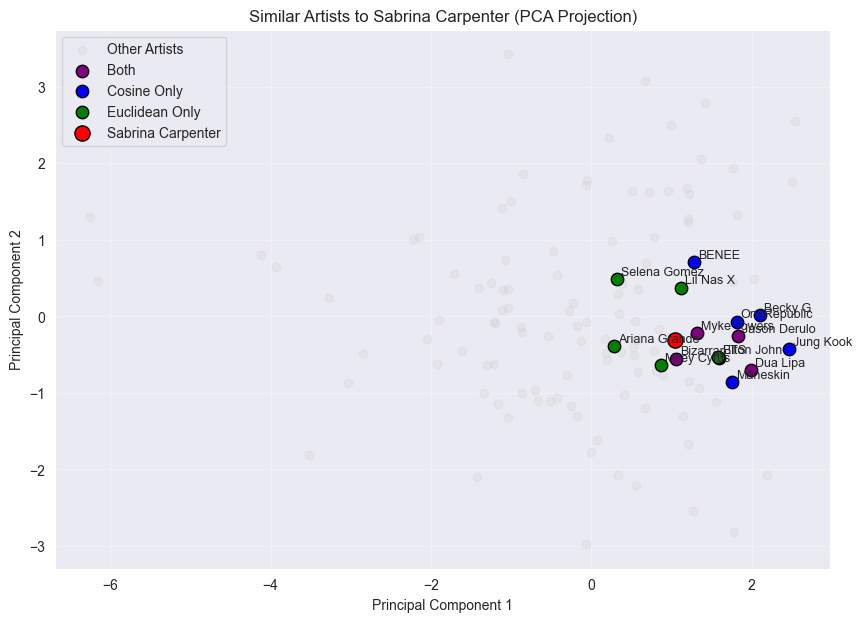

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Plot all artists in gray (background)
plt.scatter(result['PC1'], result['PC2'], color='lightgray', alpha=0.3, label='Other Artists')

# Plot each similarity group with distinct colors
color_map = {
    'Both': 'purple',
    'Cosine Only': 'blue',
    'Euclidean Only': 'green'
}

for group, color in color_map.items():
    subset = result[result['similarity_group'] == group]
    if not subset.empty:
        plt.scatter(subset['PC1'], subset['PC2'], color=color, s=80, label=group, edgecolor='black')

# Highlight Sabrina Carpenter
sabrina = result[result['Artist Name'] == 'Sabrina Carpenter']
plt.scatter(sabrina['PC1'], sabrina['PC2'], color='red', s=120, label='Sabrina Carpenter', edgecolor='black')

# Annotate similar artists
for _, row in result[result['similarity_group'] != 'Other'].iterrows():
    plt.text(row['PC1'] + 0.05, row['PC2'] + 0.05, row['Artist Name'], fontsize=9)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Similar Artists to Sabrina Carpenter (PCA Projection)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


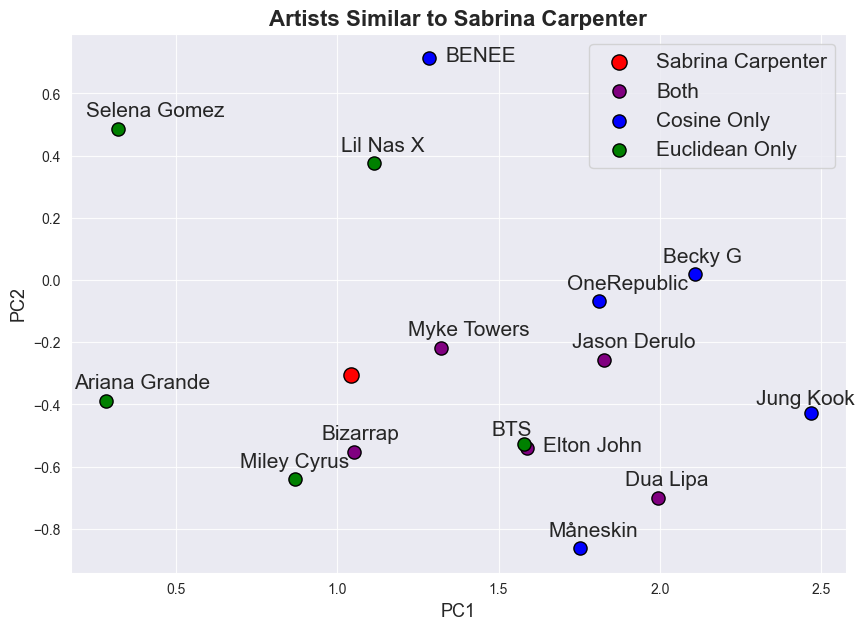

In [25]:
plt.figure(figsize=(10, 7))

focus_df = result[result['similarity_group'].isin(['Both', 'Cosine Only', 'Euclidean Only'])]

# Plot Sabrina
plt.scatter(sabrina['PC1'], sabrina['PC2'], color='red', s=120, label='Sabrina Carpenter', edgecolor='black')

# Plot similar ones
for group, color in color_map.items():
    subset = focus_df[focus_df['similarity_group'] == group]
    if not subset.empty:
        plt.scatter(subset['PC1'], subset['PC2'], color=color, s=90, label=group, edgecolor='black')
        for _, row in subset.iterrows():
            if (row['Artist Name'] == "BTS"):
                plt.text(row['PC1'] - 0.1, row['PC2'] + 0.03, row['Artist Name'], fontsize=15)
            elif (row['Artist Name'] in ["Elton John", "BENEE"]):
                    plt.text(row['PC1'] + 0.05, row['PC2'] - 0.01 , row['Artist Name'], fontsize=15)
            elif (row['Artist Name'] == "Jung Kook"):
                 plt.text(row['PC1'] - 0.17, row['PC2'] + 0.03 , row['Artist Name'], fontsize=15)
            elif (row['Artist Name'] == "Miley Cyrus"):
                plt.text(row['PC1'] - 0.17, row['PC2'] + 0.04 , row['Artist Name'], fontsize=15)
            else:
                plt.text(row['PC1'] - 0.1, row['PC2'] + 0.04, row['Artist Name'], fontsize=15)

plt.xlabel('PC1', fontsize = 13)
plt.ylabel('PC2', fontsize = 13)
plt.title('Artists Similar to Sabrina Carpenter', fontsize = 16, fontweight = 'bold')
plt.legend(fontsize = 15)
plt.grid(alpha=0.9)
plt.show()
